In [16]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA


In [17]:
df = pd.read_csv('AEP_hourly 2.csv')

In [18]:
df

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0
...,...,...
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0


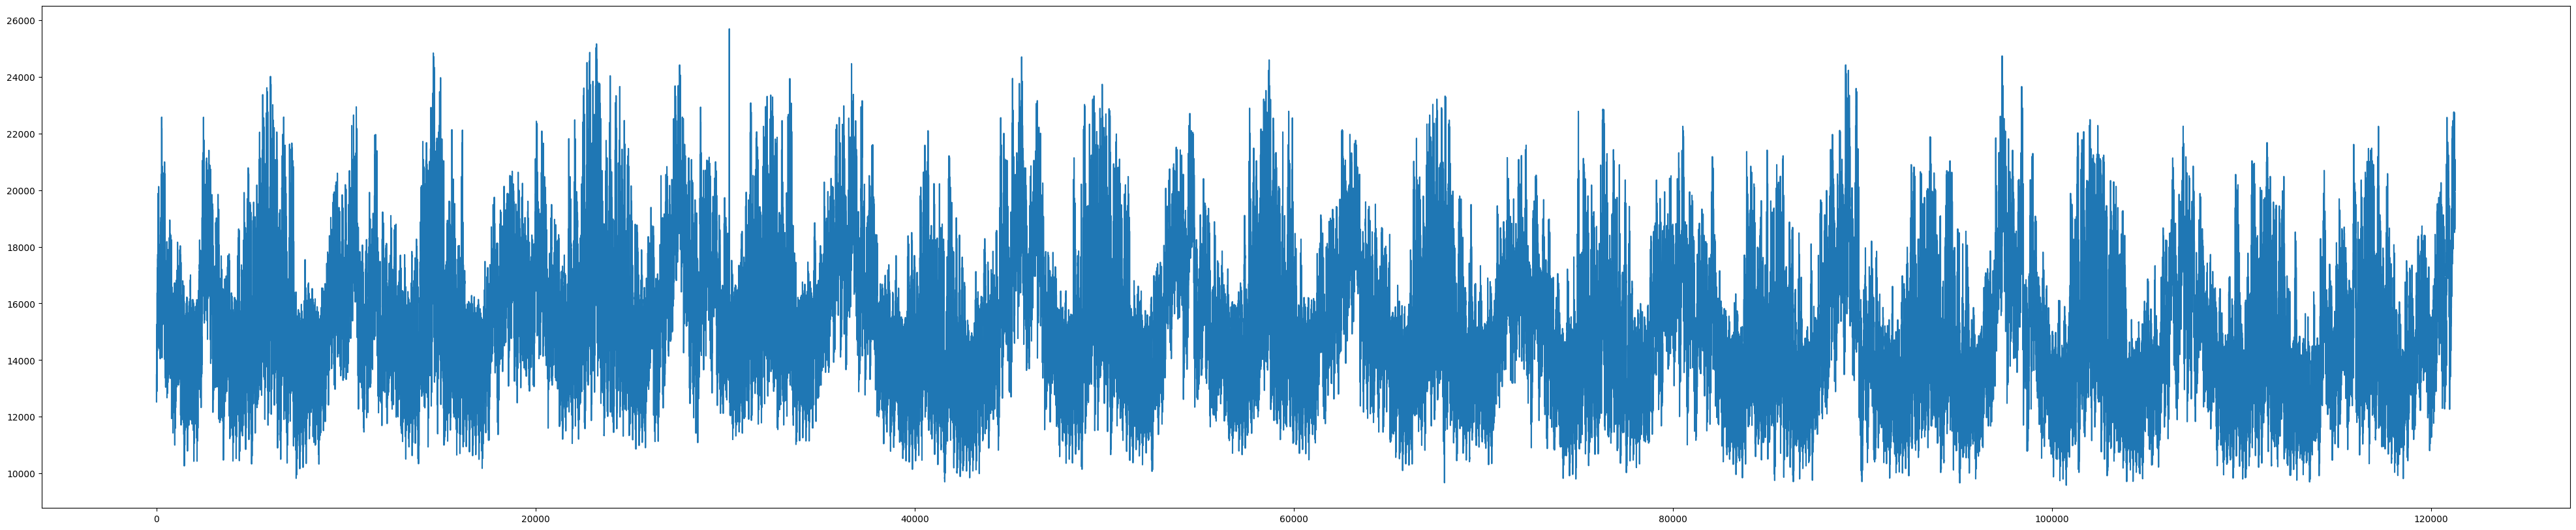

In [19]:
plt.figure(figsize=(50, 10))
df.AEP_MW.plot()
plt.show()

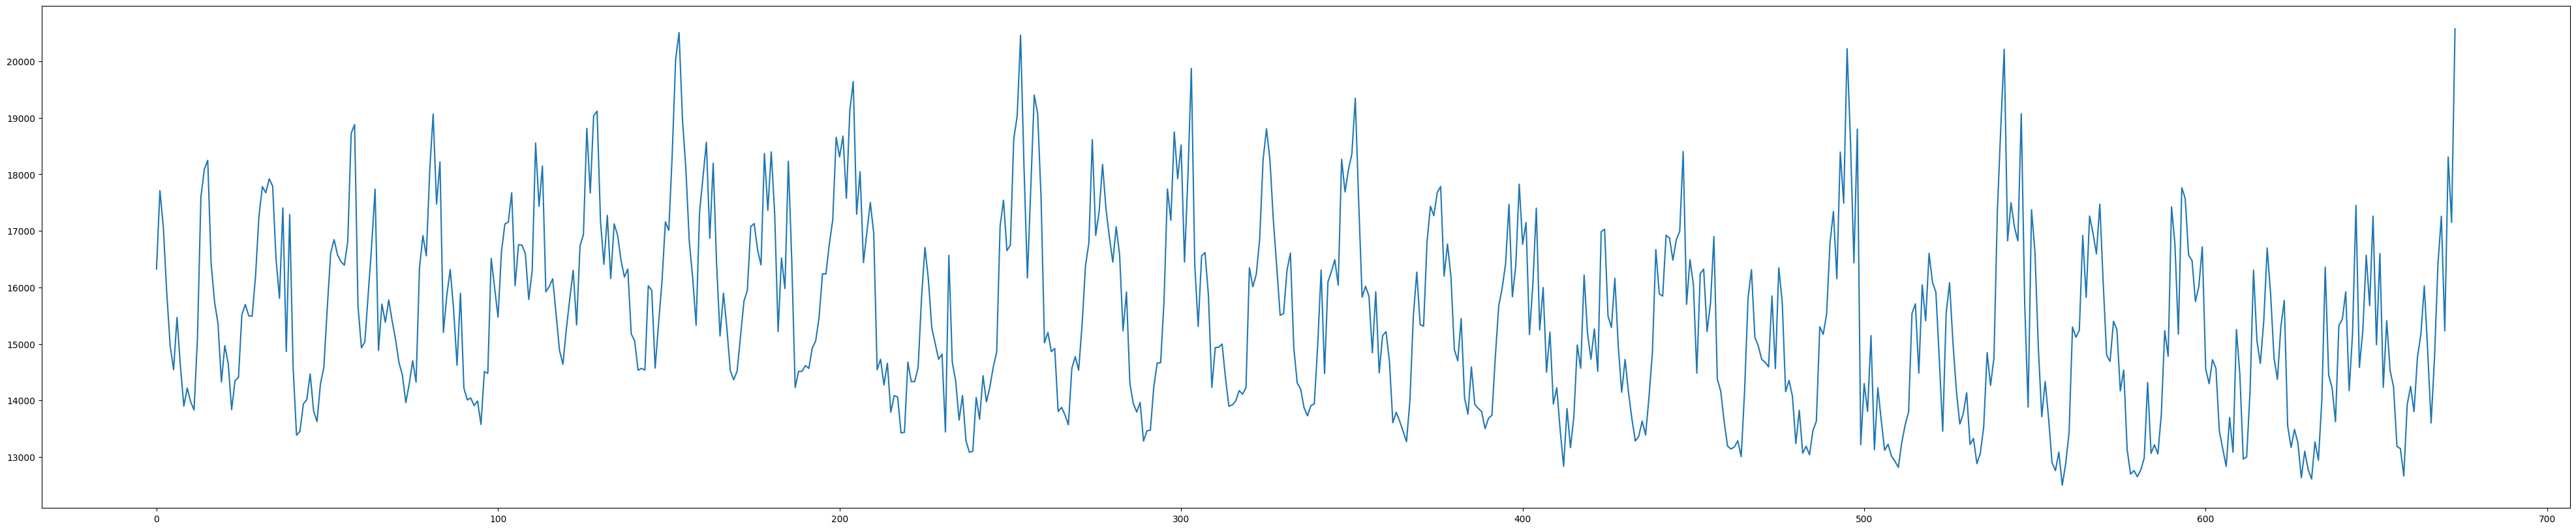

In [20]:
plt.figure(figsize=(50, 10))
df_agg = df.AEP_MW.groupby(np.arange(len(df)) // 180).mean()
df_agg.plot()
plt.show()

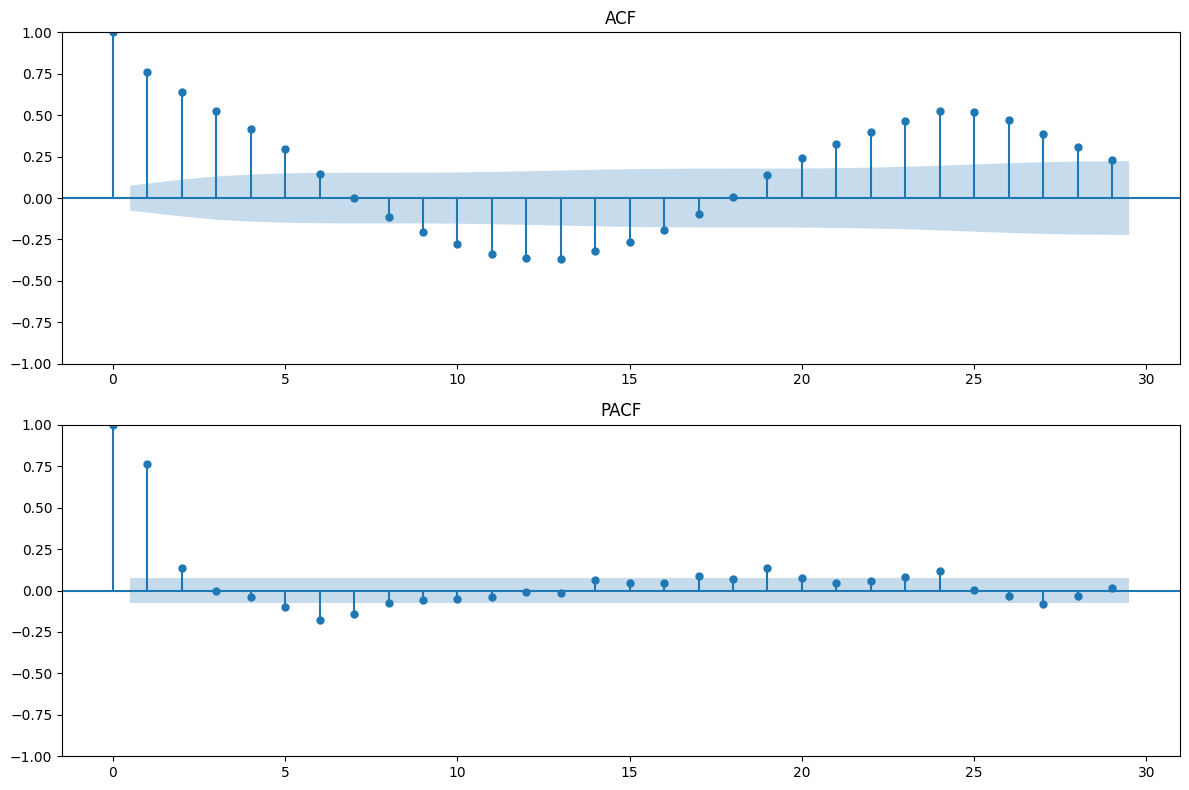

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df_agg, ax=axes[0])
axes[0].set_title("ACF")

plot_pacf(df_agg, ax=axes[1], method='ywm')
axes[1].set_title("PACF")

plt.tight_layout()
plt.show()


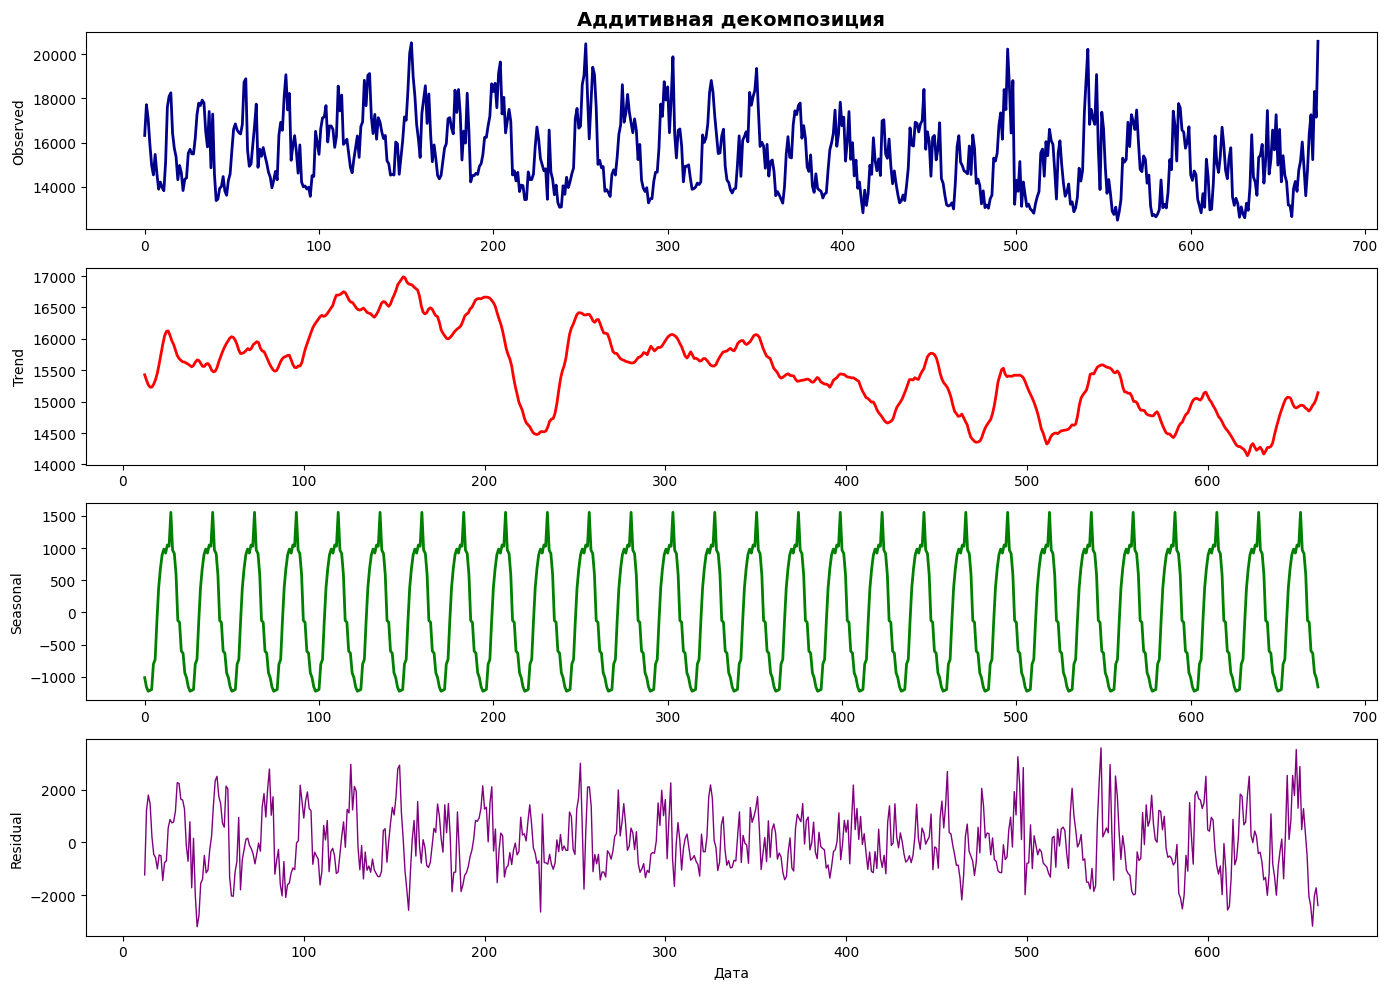

In [22]:
period = 24

decomposition_add = seasonal_decompose(df_agg, model='additive', period=period)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

decomposition_add.observed.plot(ax=axes[0], color='darkblue', linewidth=2)
axes[0].set_ylabel('Observed')
axes[0].set_title('Аддитивная декомпозиция', fontsize=14, fontweight='bold')

decomposition_add.trend.plot(ax=axes[1], color='red', linewidth=2)
axes[1].set_ylabel('Trend')

decomposition_add.seasonal.plot(ax=axes[2], color='green', linewidth=2)
axes[2].set_ylabel('Seasonal')

decomposition_add.resid.plot(ax=axes[3], color='purple', linewidth=1)
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Дата')

plt.tight_layout()
plt.show()

In [23]:
df_log = df_agg.copy()
df_log = np.log(df_log)

In [24]:
import warnings
warnings.filterwarnings("ignore")

In [25]:
# --- ADF Test ---
adf_result = adfuller(df_log)

print("ADF Test:")
print(f"  Statistic: {adf_result[0]}")
print(f"  p-value:   {adf_result[1]}")
print("  Critical values:")
for k, v in adf_result[4].items():
    print(f"    {k}: {v}")

# --- KPSS Test ---
kpss_result = kpss(df_log, regression='c', nlags='auto')

print("\nKPSS Test:")
print(f"  Statistic: {kpss_result[0]}")
print(f"  p-value:   {kpss_result[1]}")
print("  Critical values:")
for k, v in kpss_result[3].items():
    print(f"    {k}: {v}")

print()
if adf_result[1] < 0.05 and kpss_result[1] > 0.05:
    print("СТАЦИОНАРЕН")
else:
    print("НЕСТАЦИОНАРЕН")

ADF Test:
  Statistic: -3.69748152010839
  p-value:   0.004148718593784122
  Critical values:
    1%: -3.440388459298194
    5%: -2.8659694611921034
    10%: -2.569128861019929

KPSS Test:
  Statistic: 1.24088543577414
  p-value:   0.01
  Critical values:
    10%: 0.347
    5%: 0.463
    2.5%: 0.574
    1%: 0.739

НЕСТАЦИОНАРЕН


In [26]:
df_diff1 = df_log.copy()
df_diff1 = df_log.diff().dropna()

In [27]:
# --- ADF Test ---
adf_result = adfuller(df_diff1)

print("ADF Test:")
print(f"  Statistic: {adf_result[0]}")
print(f"  p-value:   {adf_result[1]}")
print("  Critical values:")
for k, v in adf_result[4].items():
    print(f"    {k}: {v}")

# --- KPSS Test ---
kpss_result = kpss(df_diff1, regression='c', nlags='auto')

print("\nKPSS Test:")
print(f"  Statistic: {kpss_result[0]}")
print(f"  p-value:   {kpss_result[1]}")
print("  Critical values:")
for k, v in kpss_result[3].items():
    print(f"    {k}: {v}")

print()
if adf_result[1] < 0.05 and kpss_result[1] > 0.05:
    print("СТАЦИОНАРЕН")
else:
    print("НЕСТАЦИОНАРЕН")

ADF Test:
  Statistic: -11.811548816038389
  p-value:   8.83627211529364e-22
  Critical values:
    1%: -3.440419374623044
    5%: -2.865983079837035
    10%: -2.5691361169972526

KPSS Test:
  Statistic: 0.023164221766313168
  p-value:   0.1
  Critical values:
    10%: 0.347
    5%: 0.463
    2.5%: 0.574
    1%: 0.739

СТАЦИОНАРЕН


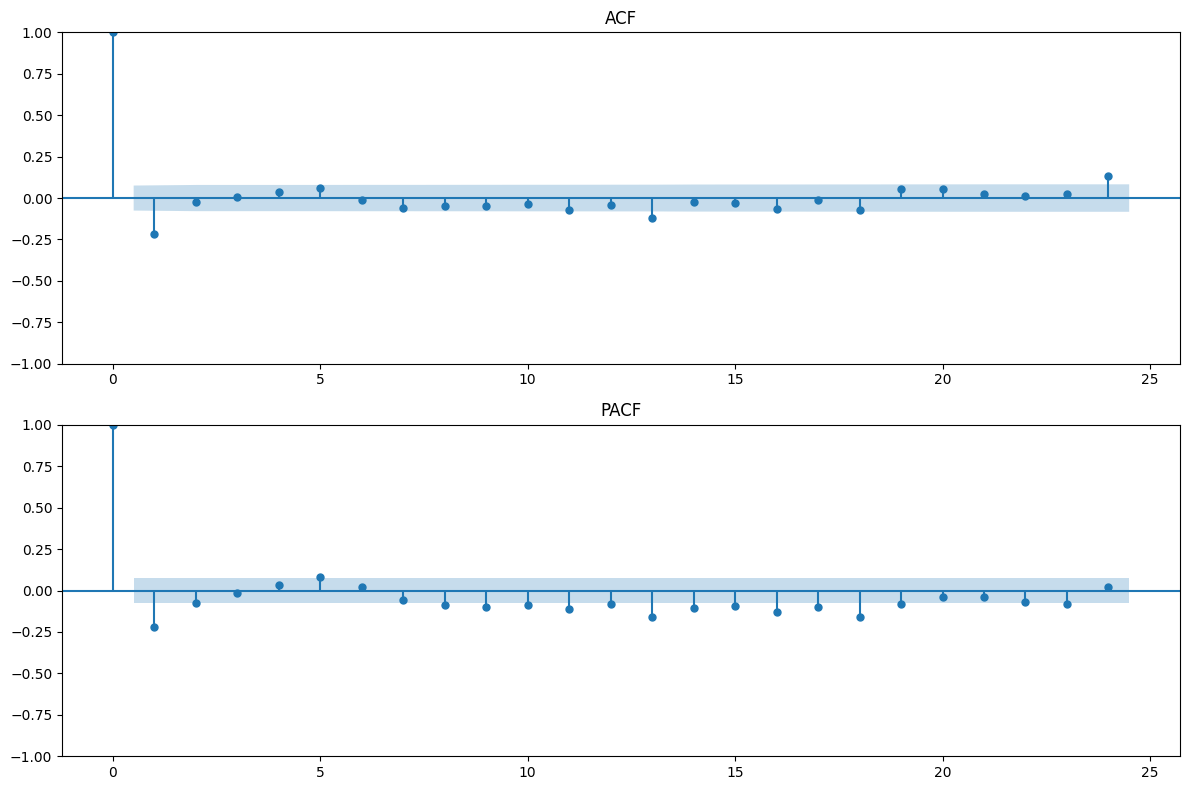

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df_diff1, ax=axes[0], lags=period)
axes[0].set_title("ACF")

plot_pacf(df_diff1, ax=axes[1], lags=period, method='ywm')
axes[1].set_title("PACF")

plt.tight_layout()
plt.show()


In [ ]:
model = ARIMA(df_agg, order=(1, 1, 1))
res = model.fit()

print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                 AEP_MW   No. Observations:                  674
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -5661.895
Date:                Thu, 18 Dec 2025   AIC                          11329.790
Time:                        16:52:32   BIC                          11343.325
Sample:                             0   HQIC                         11335.032
                                - 674                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1397      0.140      1.001      0.317      -0.134       0.413
ma.L1         -0.3563      0.140     -2.550      0.011      -0.630      -0.082
sigma2      1.175e+06   5.45e+04     21.538      0.0

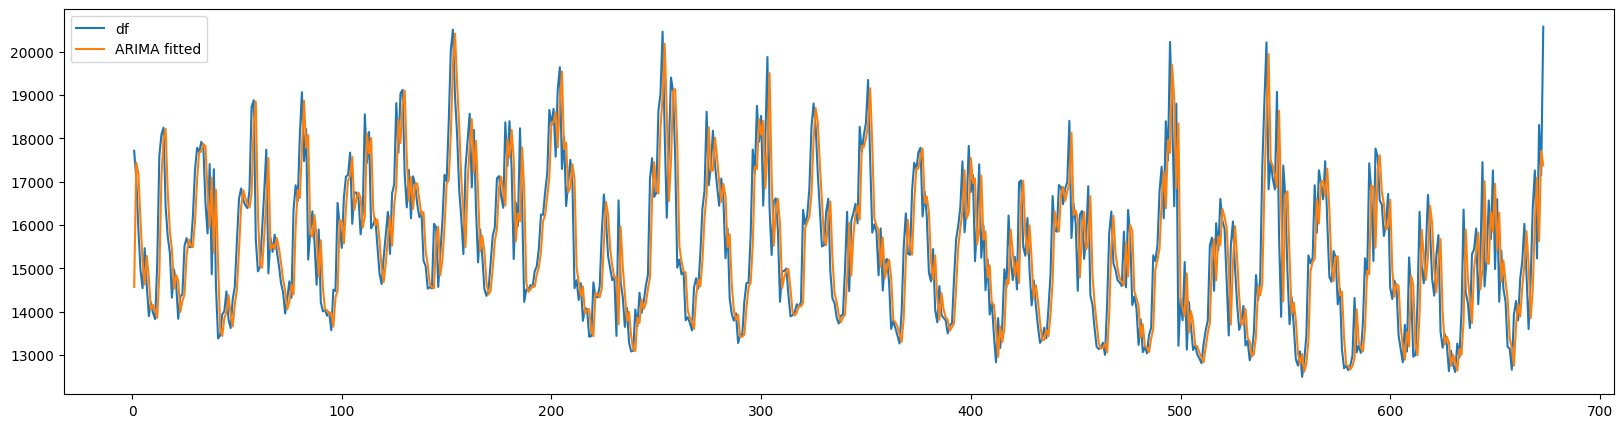

In [46]:
fitted = res.fittedvalues

plt.figure(figsize=(20, 5))

plt.plot(df_agg[1:].index, df_agg[1:], label='df')
plt.plot(fitted[1:].index, fitted[1:], label='ARIMA fitted')

plt.legend()
plt.show()

In [30]:
model = ARIMA(df_agg, order=(1, 0, 1))
res = model.fit()

print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                 AEP_MW   No. Observations:                  674
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -5642.516
Date:                Thu, 18 Dec 2025   AIC                          11293.031
Time:                        16:52:32   BIC                          11311.084
Sample:                             0   HQIC                         11300.022
                                - 674                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.55e+04    231.751     66.889      0.000     1.5e+04     1.6e+04
ar.L1          0.8361      0.028     30.205      0.000       0.782       0.890
ma.L1         -0.1561      0.046     -3.363      0.0

In [ ]:
fitted = res.fittedvalues

plt.figure(figsize=(20, 5))

plt.plot(df_agg[1:].index, df_agg[1:], label='df')
plt.plot(fitted[1:].index, fitted[1:], label='ARIMA fitted')

plt.legend()
plt.show()

In [31]:
model = ARIMA(df_agg, order=(0, 1, 1))
res = model.fit()

print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                 AEP_MW   No. Observations:                  674
Model:                 ARIMA(0, 1, 1)   Log Likelihood               -5662.346
Date:                Thu, 18 Dec 2025   AIC                          11328.692
Time:                        16:52:32   BIC                          11337.716
Sample:                             0   HQIC                         11332.187
                                - 674                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2232      0.028     -7.911      0.000      -0.279      -0.168
sigma2      1.175e+06   5.46e+04     21.530      0.000    1.07e+06    1.28e+06
Ljung-Box (L1) (Q):                   0.39   Jarque-

In [ ]:
fitted = res.fittedvalues

plt.figure(figsize=(20, 5))

plt.plot(df_agg[1:].index, df_agg[1:], label='df')
plt.plot(fitted[1:].index, fitted[1:], label='ARIMA fitted')

plt.legend()
plt.show()

In [32]:
model = ARIMA(df_agg, order=(1, 1, 0))
res = model.fit()

print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                 AEP_MW   No. Observations:                  674
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -5664.325
Date:                Thu, 18 Dec 2025   AIC                          11332.651
Time:                        16:52:32   BIC                          11341.674
Sample:                             0   HQIC                         11336.145
                                - 674                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1946      0.026     -7.426      0.000      -0.246      -0.143
sigma2      1.183e+06   5.51e+04     21.474      0.000    1.07e+06    1.29e+06
Ljung-Box (L1) (Q):                   1.69   Jarque-

In [ ]:
fitted = res.fittedvalues

plt.figure(figsize=(20, 5))

plt.plot(df_agg[1:].index, df_agg[1:], label='df')
plt.plot(fitted[1:].index, fitted[1:], label='ARIMA fitted')

plt.legend()
plt.show()